<a href="https://colab.research.google.com/github/Hniii/Machine-learning/blob/main/supervised_learning_network_intrusion_detection_systems_(NIDS)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import warnings
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE
import itertools
from xgboost import XGBClassifier
from tabulate import tabulate


In [ ]:
train=pd.read_csv('/content/Train_data.csv')

In [ ]:
test=pd.read_csv('/content/Test_data.csv')

# 1. DataFrame Overview:

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [ ]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
train.describe(include='object')

,protocol_type,service,flag,class
count,25192,25192,25192,25192
unique,3,66,11,2
top,tcp,http,SF,normal
freq,20526,8003,14973,13449


In [ ]:
train.shape

(25192, 42)

In [ ]:
train.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

# 2. Data Exploration:

In [ ]:
total = train.shape[0]
missing_columns = [col for col in train.columns if train[col].isnull().sum() > 0]
#The loop identifies columns with missing values, calculates the percentage of missing values in those columns, and displays the result.
for col in missing_columns:
    null_count = train[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

In [ ]:
print(f"Number of duplicate rows: {train.duplicated().sum()}")

Number of duplicate rows: 0


# 3.Visualization:

<Axes: xlabel='class', ylabel='count'>

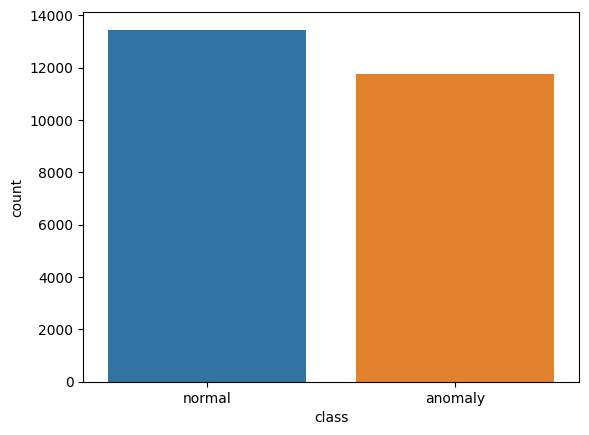

In [ ]:
sns.countplot(x=train['class'])


# 4.Data Preprocessing:

In [ ]:
print('Class distribution Training set:')
print(train['class'].value_counts())

Class distribution Training set:
normal     13449
anomaly    11743
Name: class, dtype: int64


In [ ]:
#Label Encoding: Converts categorical columns to numeric values using LabelEncoder.
def le(df):
    for col in df.columns:
        if df[col].dtype == 'object':
                label_encoder = LabelEncoder()
                df[col] = label_encoder.fit_transform(df[col])

le(train)
le(test)

In [ ]:
#Removing unnecessary columns

#train.drop(['num_outbound_cmds'], axis=1, inplace=True)
#test.drop(['num_outbound_cmds'], axis=1, inplace=True)

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2,41,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1,46,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,22,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1,22,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


In [ ]:
#X_train contains all the features or independent variables that will be used for training the machine learning model.
X_train = train.drop(['class'], axis=1)
#Y_train represents the target variable or the labels that the machine learning model will try to predict. It contains the corresponding classes or categories for each row of the training data
Y_train = train['class']

# 5.Feature Selection:
using Recursive Feature Elimination (RFE) with a Random Forest Classifier (RFC) . and subsets the X_train data to include only the selected features

In [ ]:
#The steps here  involving RandomForestClassifier and RFE (Recursive Feature Elimination) are part of the supervised learning process:

rfc = RandomForestClassifier()

rfe = RFE(rfc, n_features_to_select=10)
rfe = rfe.fit(X_train, Y_train)

feature_map = [(i, v) for i, v in itertools.zip_longest(rfe.get_support(), X_train.columns)]
selected_features = [v for i, v in feature_map if i==True]

selected_features

['protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'count',
 'same_srv_rate',
 'diff_srv_rate',
 'dst_host_srv_count',
 'dst_host_same_srv_rate']

In [ ]:
X_train = X_train[selected_features]

**Standardize the features**

In [ ]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
test = scale.fit_transform(test)

**Splits the data into training and testing sets**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, train_size=0.70, random_state=2)

In [ ]:
x_train.shape

(17634, 10)

In [ ]:
x_test.shape

(7558, 10)

In [ ]:
y_train.shape

(17634,)

In [ ]:
y_test.shape

(7558,)

# 6.Model Training and Evaluation:

In [ ]:
import time

**Logistic Regression Model:**

In [ ]:
# Initializing Logistic Regression models
clfl = LogisticRegression(max_iter=1200000)
lg_model = LogisticRegression(random_state=42)

# Training the model with timing
start_time = time.time()
clfl.fit(x_train, y_train.values.ravel())
end_time = time.time()

# Measuring training time
print("Training time: ", end_time - start_time)

# Predicting and measuring testing time
start_time = time.time()
y_test_pred = clfl.predict(x_test)
end_time = time.time()
print("Testing time: ", end_time - start_time)

# Training and test scores for the model with random_state
lg_model.fit(x_train, y_train)
lg_train_score = lg_model.score(x_train, y_train)
lg_test_score = lg_model.score(x_test, y_test)

# Outputting training and test scores
print(f"Training Score: {lg_train_score}")
print(f"Test Score: {lg_test_score}")

Training time:  0.059949398040771484
Testing time:  0.0009665489196777344
Training Score: 0.9287739593966202
Test Score: 0.9231278115903678


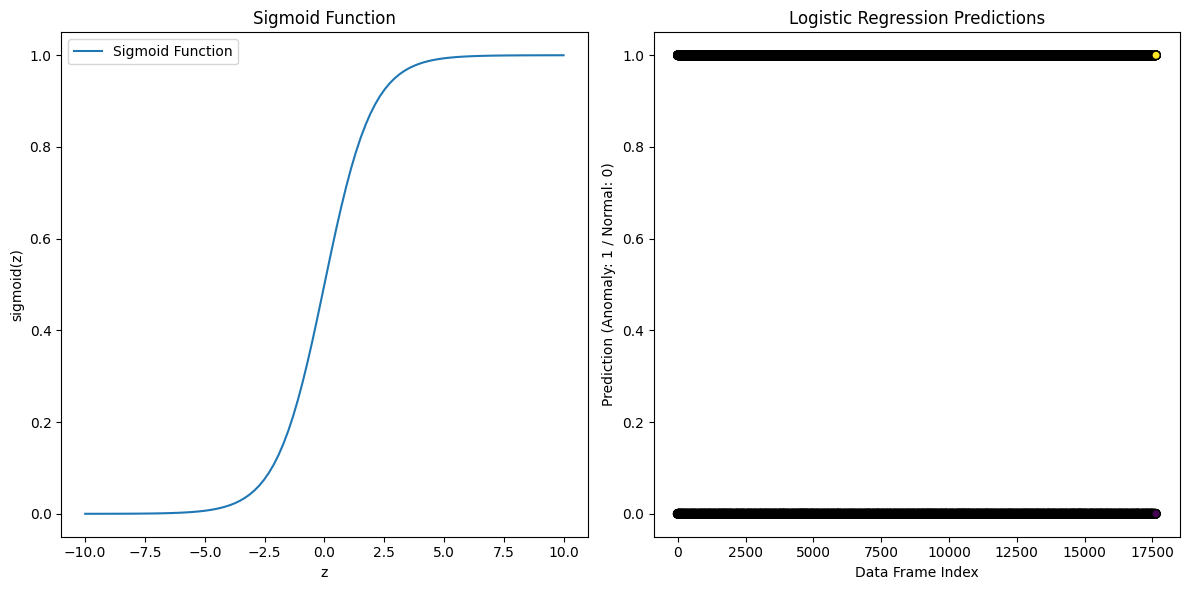

In [ ]:
# Scatter plot of the logistic regression predictions
plt.figure(figsize=(12, 6))

# Plotting sigmoid function
plt.subplot(1, 2, 1)
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))
plt.plot(z, sigmoid, label='Sigmoid Function')
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.legend()

# Plotting logistic regression predictions
plt.subplot(1, 2, 2)
plt.scatter(range(len(y_train)), clfl.predict(x_train), c=clfl.predict(x_train), cmap='viridis', marker='o', edgecolors='k')
plt.xlabel('Data Frame Index')
plt.ylabel('Prediction (Anomaly: 1 / Normal: 0)')
plt.title('Logistic Regression Predictions')
plt.tight_layout()
plt.show()

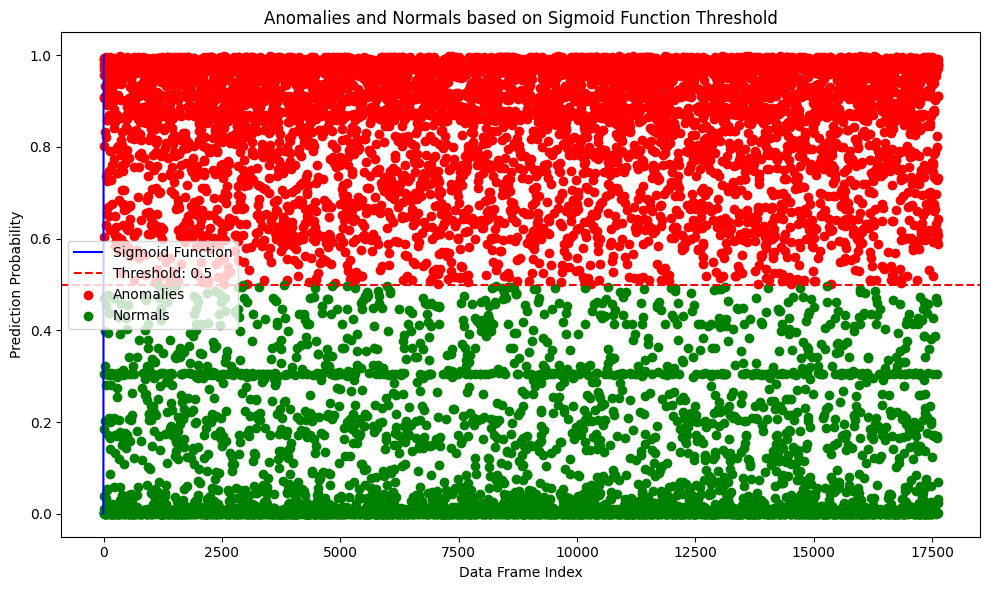

In [ ]:
# Scatter plot of the training data
plt.figure(figsize=(10, 6))

# Plotting sigmoid function
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))
plt.plot(z, sigmoid, label='Sigmoid Function', color='blue')

# Threshold line
threshold = 0.5  # Set your threshold here
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold: {threshold}')

# Probabilities from logistic regression
probabilities = clfl.predict_proba(x_train)[:, 1]

# Categorizing anomalies and normals based on threshold
anomalies = np.where(probabilities >= threshold)[0]
normals = np.where(probabilities < threshold)[0]

# Plot anomalies and normals based on threshold
plt.scatter(anomalies, probabilities[anomalies], c='red', marker='o', label='Anomalies')
plt.scatter(normals, probabilities[normals], c='green', marker='o', label='Normals')

plt.xlabel('Data Frame Index')
plt.ylabel('Prediction Probability')
plt.title('Anomalies and Normals based on Sigmoid Function Threshold')
plt.legend()
plt.tight_layout()
plt.show()

**K-Nearest Neighbors (KNN) Model**

In [ ]:
pip install optuna

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def objective(trial):
    n_neighbors = trial.suggest_int('KNN_n_neighbors', 2, 16, log=False)
    classifier_obj = KNeighborsClassifier(n_neighbors=n_neighbors)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

study_KNN = optuna.create_study(direction='maximize')
study_KNN.optimize(objective, n_trials=10)  # Perform multiple trials for hyperparameter search

best_params = study_KNN.best_trial.params
best_n_neighbors = best_params['KNN_n_neighbors']

start_time = time.time()
KNN_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
KNN_model.fit(x_train, y_train)
end_time = time.time()

training_time_knn = end_time - start_time

KNN_train_score = KNN_model.score(x_train, y_train)
KNN_test_score = KNN_model.score(x_test, y_test)

print(f"Best Parameters: {best_params}")
print(f"Train Score: {KNN_train_score}")
print(f"Test Score: {KNN_test_score}")
start_time = time.time()
KNN_model_pred = KNN_model.predict(x_test)
end_time = time.time()

testing_time_knn = end_time - start_time

print("Training Time (KNN):", training_time_knn)
print("Testing Time (KNN):", testing_time_knn)

Best Parameters: {'KNN_n_neighbors': 3}
Train Score: 0.9912101621866848
Test Score: 0.9843874040751521
Training Time (KNN): 0.0433809757232666
Testing Time (KNN): 1.4862165451049805


**Decision Tree Model**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import time

# Training a Decision Tree with default hyperparameters
clfd = DecisionTreeClassifier(criterion="entropy", max_depth=4)
start_time_default = time.time()
clfd.fit(x_train, y_train.values.ravel())
end_time_default = time.time()

# Measuring training time for the default model
training_time_default = end_time_default - start_time_default
print("Training time (Default Decision Tree): ", training_time_default)

# Hyperparameter optimization using Optuna
def objective(trial):
    dt_max_depth = trial.suggest_int('dt_max_depth', 2, 32, log=False)
    dt_max_features = trial.suggest_int('dt_max_features', 2, 10, log=False)
    classifier_obj = DecisionTreeClassifier(max_features=dt_max_features, max_depth=dt_max_depth)
    classifier_obj.fit(x_train, y_train)
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective, n_trials=30)

# Retrieving best hyperparameters and training a model with those parameters
best_params = study_dt.best_trial.params
dt = DecisionTreeClassifier(max_features=best_params['dt_max_features'], max_depth=best_params['dt_max_depth'])

start_time_optimized = time.time()
dt.fit(x_train, y_train)
end_time_optimized = time.time()

# Measuring training time for the optimized model
training_time_optimized = end_time_optimized - start_time_optimized
print("Training time (Optimized Decision Tree): ", training_time_optimized)

# Calculating and printing train and test scores for the best model
dt_train_score = dt.score(x_train, y_train)
dt_test_score = dt.score(x_test, y_test)

print(f"Best Hyperparameters: {best_params}")
print(f"Train Score (Best Decision Tree): {dt_train_score}")
print(f"Test Score (Best Decision Tree): {dt_test_score}")

# Testing time for the optimized model
start_time_testing = time.time()
dt_pred = dt.predict(x_test)
end_time_testing = time.time()

testing_time_optimized = end_time_testing - start_time_testing
print("Testing time (Optimized Decision Tree): ", testing_time_optimized)


Training time (Default Decision Tree):  0.041402578353881836
Training time (Optimized Decision Tree):  0.03632473945617676
Best Hyperparameters: {'dt_max_depth': 25, 'dt_max_features': 9}
Train Score (Best Decision Tree): 1.0
Test Score (Best Decision Tree): 0.9951045250066155
Testing time (Optimized Decision Tree):  0.002361297607421875


In [ ]:
data = [
    ["Logistic Regression", lg_train_score, lg_test_score],
    ["K-Nearest Neighbors (KNN)", KNN_train_score, KNN_test_score],
    ["Decision Tree", dt_train_score, dt_test_score]
]

# Define column names for the table
col_names = ["Model", "Train Score", "Test Score"]

# Display the data in a tabulated format
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

╒═══════════════════════════╤═══════════════╤══════════════╕
│ Model                     │   Train Score │   Test Score │
╞═══════════════════════════╪═══════════════╪══════════════╡
│ Logistic Regression       │      0.928774 │     0.923128 │
├───────────────────────────┼───────────────┼──────────────┤
│ K-Nearest Neighbors (KNN) │      0.99121  │     0.984387 │
├───────────────────────────┼───────────────┼──────────────┤
│ Decision Tree             │      1        │     0.995105 │
╘═══════════════════════════╧═══════════════╧══════════════╛


In [ ]:

from sklearn.model_selection import cross_val_score
# Define the machine learning models
SEED = 42
dtc = DecisionTreeClassifier(random_state=SEED)
knn = KNeighborsClassifier()
lr = LogisticRegression()

# Create a dictionary to hold the models
models = {
    'KNeighborsClassifier': knn,
    'LogisticRegression': lr,
    'DecisionTreeClassifier': dtc
}

# Initialize an empty dictionary to store scores
scores = {}

# Loop through each model
for name, model in models.items():
    scores[name] = {}  # Create an inner dictionary for each model
    for scorer in ['precision', 'recall']:  # Scoring metrics
        # Perform cross-validation and store the scores
        scores[name][scorer] = cross_val_score(
             model, x_train, y_train, cv=10, scoring=scorer
        )

# Calculate mean and standard deviation of scores for each model and metric
for name in models:
    for scorer in ['precision', 'recall']:
        # Calculate mean and standard deviation of scores for each model and metric
        mean = round(np.mean(scores[name][scorer]) * 100, 2)
        stdev = round(np.std(scores[name][scorer]) * 100, 2)
        print(f"Model: {name}, Metric: {scorer}")
        print(f"Mean {scorer}: {mean}%, Standard deviation: {stdev}%\n")



Model: KNeighborsClassifier, Metric: precision
Mean precision: 98.45%, Standard deviation: 0.48%

Model: KNeighborsClassifier, Metric: recall
Mean recall: 98.24%, Standard deviation: 0.54%

Model: LogisticRegression, Metric: precision
Mean precision: 91.35%, Standard deviation: 0.57%

Model: LogisticRegression, Metric: recall
Mean recall: 95.72%, Standard deviation: 0.67%

Model: DecisionTreeClassifier, Metric: precision
Mean precision: 99.55%, Standard deviation: 0.24%

Model: DecisionTreeClassifier, Metric: recall
Mean recall: 99.51%, Standard deviation: 0.18%



<Axes: >

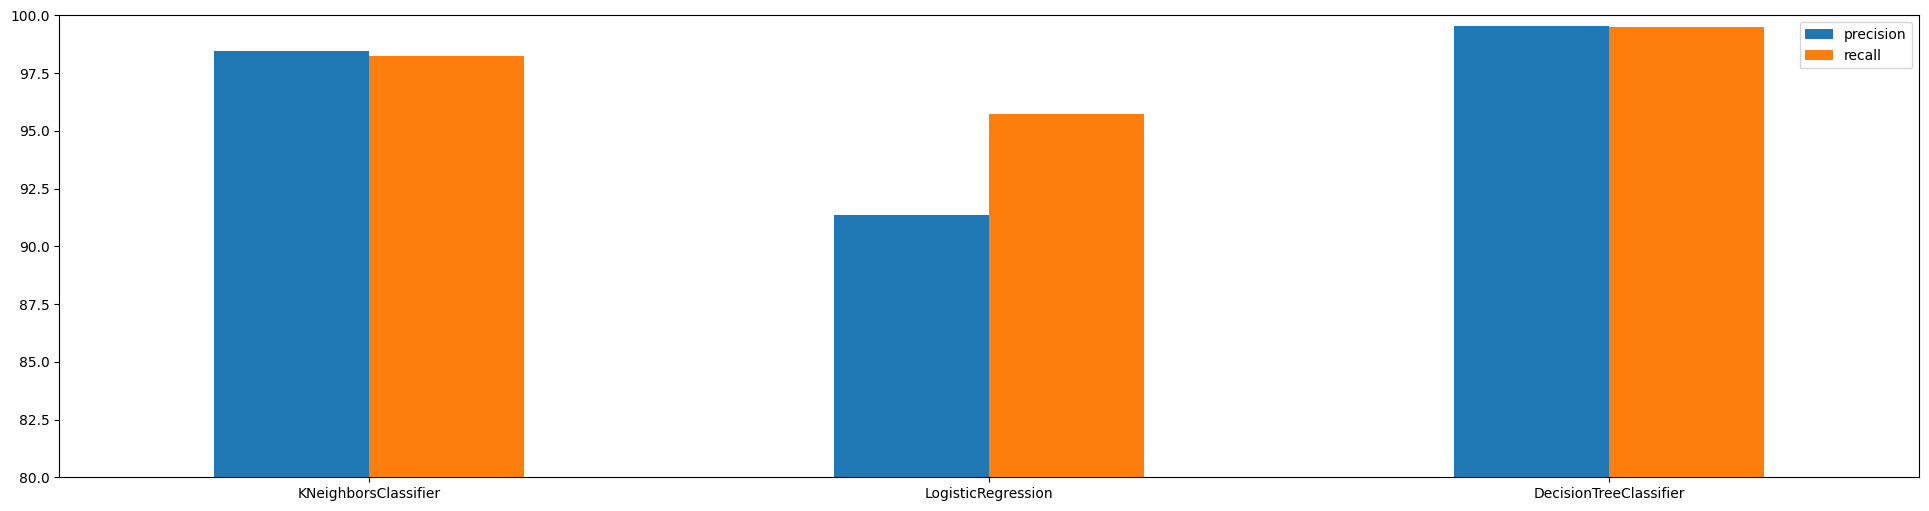

In [ ]:
for name in models:
    for scorer in ['precision','recall']:
        scores[name][scorer] = scores[name][scorer].mean()
scores=pd.DataFrame(scores).swapaxes("index", "columns")*100
scores.plot(kind = "bar",  ylim=[80,100], figsize=(24,6), rot=0)

In [ ]:
models = {}
models['KNeighborsClassifier']= knn
models['LogisticRegression']= lr
models['DecisionTreeClassifier']= dtc

In [ ]:
preds={}
for name in models:
    models[name].fit(x_train, y_train)
    preds[name] = models[name].predict(x_test)
print("Predictions complete.")

Predictions complete.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
def line(name,sym="*"):
    return sym*(25-len(name)//2)
target_names=["normal","anamoly"]
for name in models:
    print(line(name), name, 'Model Testing', line(name))
    print(confusion_matrix(y_test, preds[name]))
    print(line(name,'-'))
    print(classification_report(y_test, preds[name], target_names=target_names))

*************** KNeighborsClassifier Model Testing ***************
[[3435   63]
 [  65 3995]]
---------------
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98      3498
     anamoly       0.98      0.98      0.98      4060

    accuracy                           0.98      7558
   macro avg       0.98      0.98      0.98      7558
weighted avg       0.98      0.98      0.98      7558

**************** LogisticRegression Model Testing ****************
[[3127  371]
 [ 210 3850]]
----------------
              precision    recall  f1-score   support

      normal       0.94      0.89      0.91      3498
     anamoly       0.91      0.95      0.93      4060

    accuracy                           0.92      7558
   macro avg       0.92      0.92      0.92      7558
weighted avg       0.92      0.92      0.92      7558

************** DecisionTreeClassifier Model Testing **************
[[3483   15]
 [  26 4034]]
--------------
              pr

<Axes: >

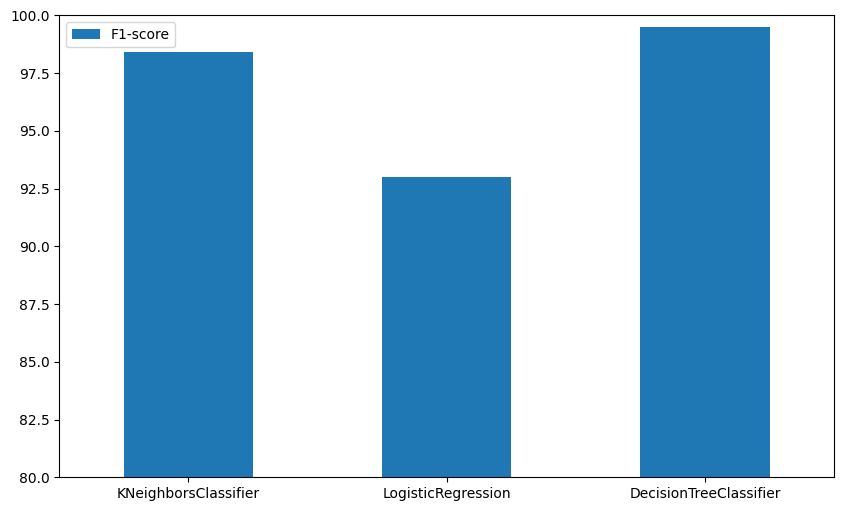

In [ ]:
f1s = {}
for name in models:
    f1s[name]=f1_score(y_test, preds[name])
f1s=pd.DataFrame(f1s.values(),index=f1s.keys(),columns=["F1-score"])*100
f1s.plot(kind = "bar",  ylim=[80,100], figsize=(10,6), rot=0)

In [ ]:

# Example single input data
single_input = {
    'protocol_type': 'tcp',
    'service': 'private',
    'flag': 'REJ',
    'src_bytes': 0,
    'dst_bytes': 0,
    'count': 229,
    'same_srv_rate': 0.04,
    'dst_host_srv_count': 10,
    'dst_host_same_srv_rate': 0.04,
    'diff_srv_rate':0.06,
}

def preprocess_input(single_input):
    # Convert the input dictionary to a DataFrame
    input_df = pd.DataFrame([single_input])

    # Label encode categorical columns
    label_encoder = LabelEncoder()
    categorical_cols = ['protocol_type', 'service', 'flag']
    for col in categorical_cols:
        input_df[col] = label_encoder.fit_transform(input_df[col])

    return input_df

def predict_with_models(input_data):
    # Preprocess the input
    processed_input = preprocess_input(input_data)

    # Assuming models clfl, knn, and dtc are already trained
    # Use the trained models to make predictions
    logistic_regression_prediction = clfl.predict(processed_input)
    knn_prediction = knn.predict(processed_input)
    decision_tree_prediction = dtc.predict(processed_input)

    return logistic_regression_prediction, knn_prediction, decision_tree_prediction

# Use the function to predict using the provided input data
log_reg_pred, knn_pred, dt_pred = predict_with_models(single_input)

print(f"Logistic Regression Prediction: {log_reg_pred}")
print(f"KNN Prediction: {knn_pred}")
print(f"Decision Tree Prediction: {dt_pred}")

Logistic Regression Prediction: [0]
KNN Prediction: [0]
Decision Tree Prediction: [0]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
